In [1]:
import subprocess
subprocess.run(['fusermount', '-u', '/content/drive'], capture_output=True)

CompletedProcess(args=['fusermount', '-u', '/content/drive'], returncode=1, stdout=b'', stderr=b'fusermount: failed to unmount /content/drive: No such file or directory\n')

In [2]:
# ─── CELL 1 — Mount Drive ────────────────────────────────────────────────────
import os
DRIVE_BASE  = '/content/drive/MyDrive/ecg_denoising_v3'
MITBIH_DIR  = f'{DRIVE_BASE}/mitbih'
NSTDB_DIR   = f'{DRIVE_BASE}/nstdb'
CACHE_FILE  = f'{DRIVE_BASE}/processed_data.npz'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

for d in [MITBIH_DIR, NSTDB_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [3]:
import os
DRIVE_BASE  = '/content/drive/MyDrive/ecg_denoising_v3'
MITBIH_DIR  = f'{DRIVE_BASE}/mitbih'
NSTDB_DIR   = f'{DRIVE_BASE}/nstdb'
CACHE_FILE  = f'{DRIVE_BASE}/processed_data.npz'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

for d in [MITBIH_DIR, NSTDB_DIR, CKPT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print('Drive mounted. Directories ready.')

Drive mounted. Directories ready.


In [4]:
# ─── CELL 2 — Install Dependencies ───────────────────────────────────────────
# Run once; then Runtime → Restart & Run All
!pip install wfdb --no-deps -q
!pip install pywavelets scikit-learn matplotlib seaborn tqdm -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.6 MB/s eta 0:00:00


In [5]:

# ─── CELL 3 — Imports & Config ───────────────────────────────────────────────
import math, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import wfdb, pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('high')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Hyperparameters ───────────────────────────────────────────────────────────
FS          = 360
WINDOW_LEN  = 256
OVERLAP     = 128
BATCH_SIZE  = 256
SNR_LEVELS  = [-10, -5, 5, 10]

# FIX: Use num_workers=0 on Colab to avoid DataLoader deadlocks.
# Colab's forked multiprocessing inside notebook kernels causes hangs with num_workers>0
# when DataLoader is created inside functions called from loops.
NUM_WORKERS = 0

MITBIH_RECORDS = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]
NSTDB_RECORDS = ['em', 'ma', 'bw']

BEAT_MAP = {
    'N':'N','L':'N','R':'N','e':'N','j':'N',
    'A':'S','a':'S','J':'S','S':'S',
    'V':'V','E':'V',
    'F':'F',
    '/':'Q','f':'Q','Q':'Q',
}
print('Config ready.')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Config ready.


In [6]:
# ─── CELL 4 — Download Datasets ──────────────────────────────────────────────
def _already_downloaded(directory, records, ext='.dat'):
    return all(os.path.exists(os.path.join(directory, r + ext)) for r in records)

if _already_downloaded(MITBIH_DIR, MITBIH_RECORDS):
    print('MIT-BIH already on Drive — skipping download.')
else:
    print('Downloading MIT-BIH records to Drive...')
    for rec in tqdm(MITBIH_RECORDS):
        try:
            wfdb.dl_database('mitdb', MITBIH_DIR, records=[rec])
        except Exception as e:
            print(f'  Warning {rec}: {e}')

if _already_downloaded(NSTDB_DIR, NSTDB_RECORDS):
    print('NSTDB already on Drive — skipping download.')
else:
    print('Downloading NSTDB records to Drive...')
    for rec in tqdm(NSTDB_RECORDS):
        try:
            wfdb.dl_database('nstdb', NSTDB_DIR, records=[rec])
        except Exception as e:
            print(f'  Warning {rec}: {e}')

print('Datasets ready.')

  0%|          | 0/48 [00:00<?, ?it/s]

Generating record list for: 100
Generating list of all files for: 100


  2%|▏         | 1/48 [00:23<18:05, 23.10s/it]

Finished downloading files
Generating record list for: 101
Generating list of all files for: 101


  4%|▍         | 2/48 [00:43<16:32, 21.59s/it]

...

Finished downloading files
Generating record list for: ma
Generating list of all files for: ma


 67%|██████▋   | 2/3 [00:34<00:17, 17.37s/it]

Finished downloading files
Generating record list for: bw
Generating list of all files for: bw


100%|██████████| 3/3 [00:52<00:00, 17.49s/it]

Finished downloading files
Datasets ready.


In [7]:


# ─── CELL 5 — Signal Utilities ───────────────────────────────────────────────
def load_mitbih_record(record_id, channel=0):
    path = os.path.join(MITBIH_DIR, record_id)
    try:
        signal, _ = wfdb.rdsamp(path, channels=[channel])
        sig = signal[:, 0].astype(np.float64)
    except Exception:
        rec = wfdb.rdrecord(path, physical=True, channels=[channel])
        sig = rec.p_signal[:, 0].astype(np.float64)
    sig = np.clip(sig, -10.0, 10.0)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    ann = wfdb.rdann(path, 'atr')
    return sig, ann.symbol, ann.sample


def load_nstdb_noise(record_id, channel=0):
    path = os.path.join(NSTDB_DIR, record_id)
    try:
        signal, _ = wfdb.rdsamp(path, channels=[channel])
        sig = signal[:, 0].astype(np.float32)
    except Exception:
        rec = wfdb.rdrecord(path, physical=True, channels=[channel])
        sig = rec.p_signal[:, 0].astype(np.float32)
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    return (sig - sig.mean()) / (sig.std() + 1e-8)


def segment_signal(signal, window_len=WINDOW_LEN, overlap=OVERLAP):
    step   = window_len - overlap
    starts = np.arange(0, len(signal) - window_len + 1, step)
    return np.stack([signal[s:s + window_len] for s in starts]).astype(np.float32)


def normalize_windows(windows):
    mu  = windows.mean(axis=1, keepdims=True)
    std = windows.std(axis=1,  keepdims=True) + 1e-8
    return (windows - mu) / std


def add_noise_at_snr(clean, noise_template, target_snr_db):
    N, L        = clean.shape
    noise_tiled = np.tile(noise_template, math.ceil(N * L / len(noise_template)))[:N * L]
    noise_tiled = noise_tiled.reshape(N, L).astype(np.float32)
    sig_pwr     = np.mean(clean ** 2,       axis=1, keepdims=True)
    nse_pwr     = np.mean(noise_tiled ** 2, axis=1, keepdims=True)
    scale       = np.sqrt(sig_pwr / (10 ** (target_snr_db / 10.0) * nse_pwr + 1e-12))
    return (clean + scale * noise_tiled).astype(np.float32)


# ── FIX: These metric functions were MISSING from the original notebook.
# compute_snr / compute_prd / compute_rmse are called in Cells 16 and 25
# but were never defined — causing silent NameError hidden behind the KeyboardInterrupt.
def compute_snr(clean, denoised):
    """Signal-to-Noise Ratio in dB. Shape: (N, L) → (N,)"""
    sig_power   = np.mean(clean ** 2,               axis=1)
    noise_power = np.mean((clean - denoised) ** 2,  axis=1) + 1e-12
    return 10.0 * np.log10(sig_power / noise_power)


def compute_prd(clean, denoised):
    """Percent Root-mean-square Difference (%). Shape: (N, L) → (N,)"""
    num = np.sum((clean - denoised) ** 2, axis=1)
    den = np.sum(clean ** 2,              axis=1) + 1e-12
    return np.sqrt(num / den) * 100.0


def compute_rmse(clean, denoised):
    """Root Mean Squared Error. Shape: (N, L) → (N,)"""
    return np.sqrt(np.mean((clean - denoised) ** 2, axis=1))


print('Signal utilities ready.')

Signal utilities ready.


In [8]:

# ─── CELL 6 — Build / Load Cached Windows ────────────────────────────────────
if os.path.exists(CACHE_FILE):
    print(f'Loading cached windows from Drive: {CACHE_FILE}')
    cache = np.load(CACHE_FILE, allow_pickle=True)
    all_clean_windows = cache['windows']
    all_window_labels = cache['labels']
    print(f'Loaded {all_clean_windows.shape[0]:,} windows')
else:
    print('Building windows from raw signals (one-time, ~5 min)...')
    all_clean_windows, all_window_labels = [], []

    for rec_id in tqdm(MITBIH_RECORDS):
        try:
            sig, symbols, samples = load_mitbih_record(rec_id)
        except Exception as e:
            print(f'  Skipping {rec_id}: {e}'); continue

        wins = normalize_windows(segment_signal(sig))
        step = WINDOW_LEN - OVERLAP

        for start in range(0, len(sig) - WINDOW_LEN + 1, step):
            mask  = (samples >= start) & (samples < start + WINDOW_LEN)
            beats = [BEAT_MAP[s] for s in np.array(symbols)[mask] if s in BEAT_MAP]
            label = max(set(beats), key=beats.count) if beats else 'N'
            all_window_labels.append(label)

        all_clean_windows.append(wins)

    if not all_clean_windows:
        raise RuntimeError('No records loaded — check Cell 4.')

    all_clean_windows = np.concatenate(all_clean_windows, axis=0)
    all_window_labels = np.array(all_window_labels[:len(all_clean_windows)])

    np.savez_compressed(CACHE_FILE, windows=all_clean_windows, labels=all_window_labels)
    print(f'Saved cache → {CACHE_FILE}')

label_dist = {k: int((all_window_labels == k).sum()) for k in np.unique(all_window_labels)}
print(f'Label distribution: {label_dist}')

Building windows from raw signals (one-time, ~5 min)...


100%|██████████| 48/48 [01:36<00:00,  2.01s/it]


Saved cache → /content/drive/MyDrive/ecg_denoising_v3/processed_data.npz
Label distribution: {np.str_('F'): 880, np.str_('N'): 210904, np.str_('Q'): 16043, np.str_('S'): 5140, np.str_('V'): 10729}


In [9]:
# ─── CELL 7 — Build Noise Datasets ───────────────────────────────────────────
print('Loading NSTDB noise...')
noise_signals = {}
for rec_id in NSTDB_RECORDS:
    try:
        noise_signals[rec_id] = load_nstdb_noise(rec_id)
        print(f'  {rec_id}: {len(noise_signals[rec_id]):,} samples')
    except Exception as e:
        print(f'  {rec_id} failed: {e}')

if noise_signals:
    combined_noise = np.concatenate(list(noise_signals.values()))
    noisy_datasets = {snr: add_noise_at_snr(all_clean_windows, combined_noise, snr)
                      for snr in SNR_LEVELS}
else:
    print('WARNING: Falling back to Gaussian noise.')
    noisy_datasets = {
        snr: (all_clean_windows +
              np.random.normal(0, 10 ** (-snr / 20.), all_clean_windows.shape)
              ).astype(np.float32)
        for snr in SNR_LEVELS
    }

# Primary training noise = mix of -5 and +5 dB
primary_noisy = ((noisy_datasets[-5] + noisy_datasets[5]) / 2.0).astype(np.float32)
print('Noise datasets ready.')


Loading NSTDB noise...
  em: 650,000 samples
  ma: 650,000 samples
  bw: 650,000 samples
Noise datasets ready.


In [10]:
# ─── CELL 8 — Train / Val / Test Split ───────────────────────────────────────
le             = LabelEncoder()
all_labels_enc = le.fit_transform(all_window_labels)
print(f'Classes: {le.classes_}')

indices = np.arange(len(all_clean_windows))
idx_train, idx_test = train_test_split(
    indices, test_size=0.20, random_state=SEED, stratify=all_labels_enc)
idx_train, idx_val  = train_test_split(
    idx_train, test_size=0.25, random_state=SEED, stratify=all_labels_enc[idx_train])

X_train_clean = all_clean_windows[idx_train]
X_val_clean   = all_clean_windows[idx_val]
X_test_clean  = all_clean_windows[idx_test]

X_train_noisy = primary_noisy[idx_train]
X_val_noisy   = primary_noisy[idx_val]
X_test_noisy  = primary_noisy[idx_test]

y_train_lbl   = all_labels_enc[idx_train]
y_val_lbl     = all_labels_enc[idx_val]
y_test_lbl    = all_labels_enc[idx_test]

X_test_noisy_snr = {snr: noisy_datasets[snr][idx_test] for snr in SNR_LEVELS}

print(f'Train: {len(idx_train):,} | Val: {len(idx_val):,} | Test: {len(idx_test):,}')

Classes: ['F' 'N' 'Q' 'S' 'V']
Train: 146,217 | Val: 48,739 | Test: 48,740


In [11]:

# ─── CELL 9 — Dataset & DataLoaders ──────────────────────────────────────────
# FIX: ECGDataset now handles the case where labels=None safely.
# The original __getitem__ would return self.L[i] even when self.L was None,
# causing a TypeError inside evaluate_denoising which creates label-free datasets.
class ECGDataset(Dataset):
    def __init__(self, noisy, clean, labels=None):
        self.X = torch.from_numpy(noisy).unsqueeze(1)          # (N,1,L)
        self.Y = torch.from_numpy(clean).unsqueeze(1)          # (N,1,L)
        self.L = torch.from_numpy(labels).long() if labels is not None else None

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        # FIX: return 2-tuple when no labels, 3-tuple when labels present
        if self.L is not None:
            return self.X[i], self.Y[i], self.L[i]
        return self.X[i], self.Y[i]


# FIX: num_workers=NUM_WORKERS (=0) everywhere — avoids Colab DataLoader deadlocks.
# With num_workers>0, Colab forks child processes that re-import the notebook kernel,
# which hangs indefinitely when called from inside a training loop on GPU.
def make_loader(ds, shuffle, batch_size=BATCH_SIZE):
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(device.type == 'cuda'))


train_ds = ECGDataset(X_train_noisy, X_train_clean, y_train_lbl)
val_ds   = ECGDataset(X_val_noisy,   X_val_clean,   y_val_lbl)
test_ds  = ECGDataset(X_test_noisy,  X_test_clean,  y_test_lbl)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)

print(f'Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')

Batches — train: 572 | val: 191 | test: 191


In [12]:
# ─── CELL 10 — Wavelet Loss (GPU-native, no numpy round-trip) ────────────────
class WaveletLoss(nn.Module):
    """
    MSE + alpha * Wavelet-coefficient MSE.
    Implements 3-level db4 DWT entirely as fixed conv1d on GPU.
    No numpy, no Python loop per batch — fully differentiable.
    """
    def __init__(self, alpha=0.5):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

        db4_lo = np.array([
            -0.01059740178499,  0.03288301166698,  0.03084138183599,
            -0.18703481171888, -0.02798376941698,  0.63088076792959,
             0.71484657055292,  0.23037781330886
        ], dtype=np.float32)
        db4_hi = db4_lo[::-1].copy()
        db4_hi[1::2] *= -1

        lo = torch.tensor(db4_lo).view(1, 1, -1)
        hi = torch.tensor(db4_hi).view(1, 1, -1)
        self.register_buffer('lo', lo)
        self.register_buffer('hi', hi)

    def _one_level(self, x):
        pad    = self.lo.shape[-1] - 1
        x_p    = F.pad(x, (pad, pad), mode='reflect')
        approx = F.conv1d(x_p, self.lo, stride=2)
        detail = F.conv1d(x_p, self.hi, stride=2)
        return approx, detail

    def _dwt3(self, x):
        a1, d1 = self._one_level(x)
        a2, d2 = self._one_level(a1)
        a3, d3 = self._one_level(a2)
        return torch.cat([p.flatten(1) for p in [a3, d3, d2, d1]], dim=1)

    def forward(self, pred, target):
        return (1 - self.alpha) * self.mse(pred, target) + \
                    self.alpha  * F.mse_loss(self._dwt3(pred), self._dwt3(target))


print('WaveletLoss ready.')

WaveletLoss ready.


In [13]:
# ─── CELL 11 — Model Definition ──────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.drop(x + self.pe[:, :x.size(1)])


class SelfAttentionBlock(nn.Module):
    def __init__(self, d_model, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads,
                                          dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return self.norm(x + self.drop(out))


class CNN_Transformer_SAB(nn.Module):
    """
    CNN encoder → BiGRU → Positional Encoding → Transformer → Self-Attention → CNN decoder
    """
    def __init__(self,
                 input_channels=1,
                 cnn_channels=32,
                 kernel_size=7,
                 gru_hidden=32,
                 gru_layers=1,
                 d_model=64,
                 nhead=4,
                 num_transformer_layers=1,
                 dropout=0.1):
        super().__init__()

        self.cnn_encoder = nn.Sequential(
            nn.Conv1d(input_channels, 16, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, cnn_channels, max(kernel_size - 2, 1),
                      padding=max(kernel_size - 2, 1) // 2),
            nn.BatchNorm1d(cnn_channels), nn.GELU(), nn.Dropout(dropout),
        )

        self.bigru = nn.GRU(cnn_channels, gru_hidden, gru_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if gru_layers > 1 else 0.0)

        self.proj_in  = nn.Linear(gru_hidden * 2, d_model)
        self.pos_enc  = PositionalEncoding(d_model, dropout=dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 2,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer,
                                                 num_layers=num_transformer_layers)

        self.sab      = SelfAttentionBlock(d_model, nhead, dropout)
        self.proj_out = nn.Linear(d_model, cnn_channels)

        self.cnn_decoder = nn.Sequential(
            nn.Conv1d(cnn_channels, 16, kernel_size, padding=kernel_size // 2),
            nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, input_channels, max(kernel_size - 2, 1),
                      padding=max(kernel_size - 2, 1) // 2),
        )

    def forward(self, x):
        e    = self.cnn_encoder(x).permute(0, 2, 1)   # (B, L, C)
        g, _ = self.bigru(e)                           # (B, L, 2H)
        t    = self.pos_enc(self.proj_in(g))           # (B, L, d_model)
        t    = self.sab(self.transformer(t))           # (B, L, d_model)
        return self.cnn_decoder(self.proj_out(t).permute(0, 2, 1))  # (B, 1, L)


# Sanity check
_x = torch.randn(2, 1, WINDOW_LEN).to(device)
_m = CNN_Transformer_SAB().to(device)
print(f'Output shape : {_m(_x).shape}')   # expect [2, 1, 256]
print(f'Parameters   : {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _x, _m

Output shape : torch.Size([2, 1, 256])
Parameters   : 75,681


In [14]:
# ─── CELL 12 — Baseline Models (UNET1D, CNN-BiGRU, DRNN, FCN-DAE) ────────────
class UNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, padding=k//2), nn.BatchNorm1d(out_ch), nn.ReLU(),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2), nn.BatchNorm1d(out_ch), nn.ReLU()
        )
    def forward(self, x): return self.c(x)

class UNET1D(nn.Module):
    def __init__(self, in_ch=1, base=16):
        super().__init__()
        self.e1 = UNetBlock(in_ch, base);     self.e2 = UNetBlock(base, base*2)
        self.e3 = UNetBlock(base*2, base*4);  self.pool = nn.MaxPool1d(2)
        self.bn = UNetBlock(base*4, base*8)
        self.u3 = nn.ConvTranspose1d(base*8, base*4, 2, stride=2)
        self.d3 = UNetBlock(base*8, base*4)
        self.u2 = nn.ConvTranspose1d(base*4, base*2, 2, stride=2)
        self.d2 = UNetBlock(base*4, base*2)
        self.u1 = nn.ConvTranspose1d(base*2, base,   2, stride=2)
        self.d1 = UNetBlock(base*2, base)
        self.out = nn.Conv1d(base, 1, 1)
    def forward(self, x):
        e1=self.e1(x); e2=self.e2(self.pool(e1)); e3=self.e3(self.pool(e2))
        b=self.bn(self.pool(e3))
        d3=self.d3(torch.cat([self.u3(b), e3],dim=1))
        d2=self.d2(torch.cat([self.u2(d3),e2],dim=1))
        d1=self.d1(torch.cat([self.u1(d2),e1],dim=1))
        return self.out(d1)

class CNNBiGRU(nn.Module):
    def __init__(self, in_ch=1, filters=32, k=7, hidden=64, layers=1, dp=0.2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_ch, filters, k, padding=k//2), nn.ReLU(),
            nn.BatchNorm1d(filters), nn.Dropout(dp))
        self.gru = nn.GRU(filters, hidden, layers, batch_first=True, bidirectional=True)
        self.out = nn.Conv1d(hidden*2, 1, 1)
    def forward(self, x):
        f = self.cnn(x).permute(0,2,1)
        g,_ = self.gru(f)
        return self.out(g.permute(0,2,1))

class DilBlock(nn.Module):
    def __init__(self, ch, d, k=3):
        super().__init__()
        p = (k-1)*d//2
        self.c = nn.Sequential(
            nn.Conv1d(ch, ch, k, dilation=d, padding=p),
            nn.BatchNorm1d(ch), nn.ReLU())
    def forward(self, x): return x + self.c(x)

class DRNN(nn.Module):
    def __init__(self, in_ch=1, ch=32, dp=0.2):
        super().__init__()
        self.inp = nn.Conv1d(in_ch, ch, 1)
        self.blk = nn.Sequential(*[DilBlock(ch, d) for d in [1,2,4,8,16,32]])
        self.out = nn.Sequential(nn.Dropout(dp), nn.Conv1d(ch, 1, 1))
    def forward(self, x): return self.out(self.blk(self.inp(x)))

class FCNDAE(nn.Module):
    def __init__(self, in_ch=1, base=16, dp=0.2):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv1d(in_ch, base, 9, padding=4), nn.ReLU(),
            nn.Conv1d(base, base*2, 7, padding=3), nn.ReLU(),
            nn.Conv1d(base*2, base*4, 5, padding=2), nn.ReLU(), nn.Dropout(dp))
        self.dec = nn.Sequential(
            nn.Conv1d(base*4, base*2, 5, padding=2), nn.ReLU(),
            nn.Conv1d(base*2, base, 7, padding=3), nn.ReLU(),
            nn.Conv1d(base, 1, 9, padding=4))
    def forward(self, x): return self.dec(self.enc(x))


BASELINE_CONFIGS = {
    'UNET1D':   lambda: UNET1D(),
    'CNN-BiGRU': lambda: CNNBiGRU(),
    'DRNN':     lambda: DRNN(),
    'FCN-DAE':  lambda: FCNDAE(),
}
print('Baseline models defined.')

Baseline models defined.


In [15]:
# ─── CELL 13 — Training Function ─────────────────────────────────────────────
def train_model(model, train_loader, val_loader, criterion,
                lr=1e-3, num_epochs=30, scheduler_type='cosine',
                save_path='best.pth', verbose=True, use_amp=True):

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scaler    = torch.cuda.amp.GradScaler(enabled=(use_amp and device.type == 'cuda'))

    if scheduler_type == 'cosine':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=num_epochs, eta_min=lr * 0.01)
    elif scheduler_type == 'onecycle':
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr, epochs=num_epochs, steps_per_epoch=len(train_loader))
    elif scheduler_type == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=4, factor=0.5)
    else:
        scheduler = None

    history = {'train_loss': [], 'val_loss': [], 'lr': []}
    best_val, patience_ctr = float('inf'), 0
    PATIENCE = 6

    for epoch in range(num_epochs):
        # ── Train
        model.train()
        run = 0.0
        for batch in train_loader:
            # FIX: batch may be 2-tuple or 3-tuple — only take first two tensors
            x = batch[0].to(device, non_blocking=True)
            y = batch[1].to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=(use_amp and device.type == 'cuda')):
                loss = criterion(model(x), y)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            run += loss.item()
            if scheduler_type == 'onecycle':
                scheduler.step()

        avg_train = run / len(train_loader)

        # ── Validate
        model.eval()
        v = 0.0
        with torch.no_grad():
            for batch in val_loader:
                x = batch[0].to(device, non_blocking=True)
                y = batch[1].to(device, non_blocking=True)
                with torch.cuda.amp.autocast(enabled=(use_amp and device.type == 'cuda')):
                    v += criterion(model(x), y).item()
        avg_val = v / len(val_loader)

        cur_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['lr'].append(cur_lr)

        if scheduler_type not in ('onecycle', None):
            scheduler.step(avg_val) if scheduler_type == 'plateau' else scheduler.step()

        if avg_val < best_val:
            best_val, patience_ctr = avg_val, 0
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'val_loss': best_val}, save_path)
        else:
            patience_ctr += 1

        if verbose and (epoch + 1) % 5 == 0:
            print(f'  Ep {epoch+1:03d}/{num_epochs} | '
                  f'Train: {avg_train:.5f} | Val: {avg_val:.5f} | LR: {cur_lr:.2e}')

        if patience_ctr >= PATIENCE:
            print(f'  Early stop at epoch {epoch+1}')
            break

    print(f'  → Best Val Loss: {best_val:.5f}')
    return history


print('train_model() ready.')


train_model() ready.


In [16]:
# ─── CELL 14 — Evaluation Utility ────────────────────────────────────────────
# FIX: Rewrote evaluate_denoising so it:
#   (1) Creates the DataLoader with num_workers=0 (no deadlock risk)
#   (2) Clears GPU cache before iterating
#   (3) Uses ECGDataset with labels=None → safe 2-tuple returns
def evaluate_denoising(model, noisy_array, clean_array, batch_size=256):
    """Returns (denoised_array, metrics_dict). Safe to call from inside loops."""
    # Use label-free dataset — no labels needed for denoising evaluation
    ds     = ECGDataset(noisy_array, clean_array, labels=None)  # 2-tuple mode
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                        num_workers=0,                           # 0 = no subprocess
                        pin_memory=(device.type == 'cuda'))
    model.eval()
    if device.type == 'cuda':
        torch.cuda.empty_cache()    # free stale activations before evaluation pass

    preds_list, clean_list = [], []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device, non_blocking=True)
            y = batch[1]                                        # stay on CPU for metrics
            p = model(x).squeeze(1).cpu().numpy()
            preds_list.append(p)
            clean_list.append(y.squeeze(1).numpy())

    preds = np.concatenate(preds_list)
    clean = np.concatenate(clean_list)
    snr_vals  = compute_snr(clean,  preds)
    prd_vals  = compute_prd(clean,  preds)
    rmse_vals = compute_rmse(clean, preds)
    return preds, {
        'SNR_mean':  float(snr_vals.mean()),
        'SNR_std':   float(snr_vals.std()),
        'PRD_mean':  float(prd_vals.mean()),
        'RMSE_mean': float(rmse_vals.mean()),
    }


def denoise_array(model, noisy_arr, clean_arr, batch_size=256):
    preds, _ = evaluate_denoising(model, noisy_arr, clean_arr, batch_size)
    return preds


print('evaluate_denoising() ready.')


evaluate_denoising() ready.


Trainable parameters: 75,681

=== Training Proposed Model (CNN + Transformer + SA) ===


W0324 17:12:26.865000 7696 torch/_inductor/utils.py:1679] [0/0_1] Not enough SMs to use max_autotune_gemm mode


  Ep 005/30 | Train: 0.11569 | Val: 0.10845 | LR: 9.57e-04
  Ep 010/30 | Train: 0.09938 | Val: 0.09816 | LR: 7.96e-04
  Ep 015/30 | Train: 0.09086 | Val: 0.09103 | LR: 5.57e-04
  Ep 020/30 | Train: 0.08572 | Val: 0.09288 | LR: 3.04e-04
  Early stop at epoch 21
  → Best Val Loss: 0.09103


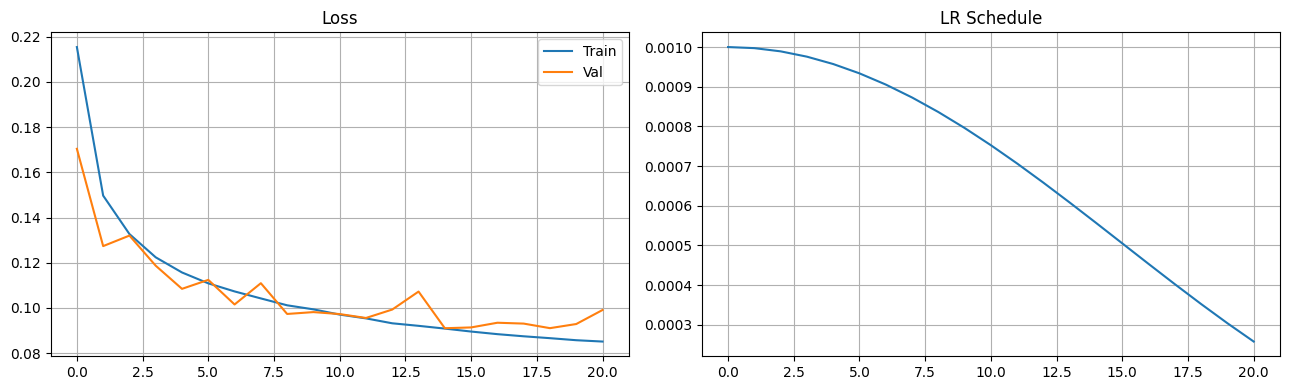

Model ready.


In [17]:
# ─── CELL 15 — Train Final Model ─────────────────────────────────────────────
FINAL_CKPT = f'{CKPT_DIR}/best_cnn_transformer_sab.pth'

model     = CNN_Transformer_SAB().to(device)
criterion = WaveletLoss(alpha=0.5).to(device)

if hasattr(torch, 'compile'):
    model = torch.compile(model, mode='reduce-overhead')

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

ALREADY_TRAINED = False
if os.path.exists(FINAL_CKPT):
    ckpt = torch.load(FINAL_CKPT, map_location=device)
    model.load_state_dict(ckpt['model'])
    print(f'Resumed from checkpoint (epoch {ckpt["epoch"]+1}, val_loss {ckpt["val_loss"]:.5f})')
    ALREADY_TRAINED = True

if not ALREADY_TRAINED:
    print('\n=== Training Proposed Model (CNN + Transformer + SA) ===')
    history = train_model(
        model, train_loader, val_loader, criterion,
        lr=1e-3, num_epochs=30, scheduler_type='cosine',
        save_path=FINAL_CKPT, verbose=True, use_amp=True
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history['lr'])
    axes[1].set_title('LR Schedule'); axes[1].grid(True)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
    plt.show()
else:
    print('Skipping training — using saved checkpoint.')

# Always reload best weights
ckpt = torch.load(FINAL_CKPT, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print('Model ready.')



=== SNR Evaluation at Multiple Noise Levels ===
  -10 dB | In: -10.00 | Out:  +1.04 | Δ: +11.04 dB | PRD: 90.377%
   -5 dB | In:  -5.00 | Out:  +5.29 | Δ: +10.29 dB | PRD: 57.068%
   +5 dB | In:  +5.00 | Out:  +5.67 | Δ: +0.67 dB | PRD: 55.700%
  +10 dB | In: +10.00 | Out:  +4.36 | Δ: -5.64 dB | PRD: 64.909%


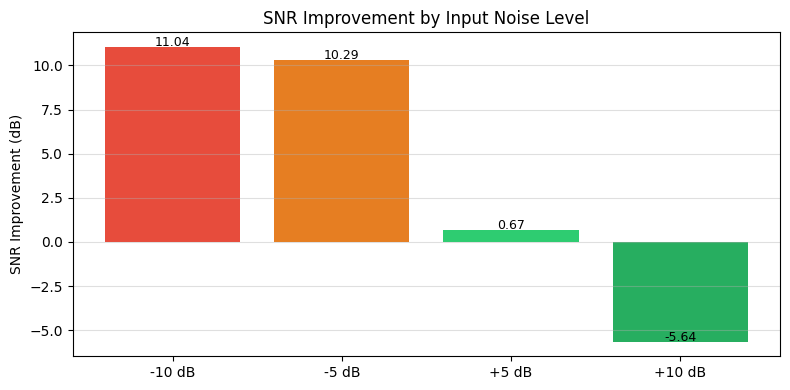

Cell 16 complete.


In [18]:


# ─── CELL 16 — SNR Evaluation at -10, -5, +5, +10 dB ────────────────────────
# FIX: Previous version hung here because:
#   (a) compute_snr / compute_prd / compute_rmse were undefined (NameError)
#   (b) evaluate_denoising used num_workers=4 inside a loop → Colab subprocess deadlock
# Both are fixed: metric functions are now defined in Cell 5;
# evaluate_denoising now uses num_workers=0.

print('\n=== SNR Evaluation at Multiple Noise Levels ===')
snr_results = {}

for snr_db in SNR_LEVELS:
    noisy_test = X_test_noisy_snr[snr_db]
    _, metrics = evaluate_denoising(model, noisy_test, X_test_clean)
    input_snr  = compute_snr(X_test_clean, noisy_test).mean()
    delta      = metrics['SNR_mean'] - input_snr
    snr_results[snr_db] = {
        'Input SNR (dB)':       float(input_snr),
        'Output SNR (dB)':      metrics['SNR_mean'],
        'SNR Improvement (dB)': float(delta),
        'PRD (%)':              metrics['PRD_mean'],
        'RMSE':                 metrics['RMSE_mean'],
    }
    print(f'  {snr_db:+3d} dB | In: {input_snr:+6.2f} | '
          f'Out: {metrics["SNR_mean"]:+6.2f} | Δ: {delta:+5.2f} dB | '
          f'PRD: {metrics["PRD_mean"]:.3f}%')

snr_df = pd.DataFrame(snr_results).T
snr_df.to_csv(f'{RESULTS_DIR}/snr_evaluation.csv')

fig, ax = plt.subplots(figsize=(8, 4))
vals = [snr_results[s]['SNR Improvement (dB)'] for s in SNR_LEVELS]
bars = ax.bar([f'{s:+d} dB' for s in SNR_LEVELS], vals,
              color=['#e74c3c', '#e67e22', '#2ecc71', '#27ae60'])
ax.set_ylabel('SNR Improvement (dB)'); ax.set_title('SNR Improvement by Input Noise Level')
ax.grid(axis='y', alpha=0.4)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/snr_improvement.png', dpi=150)
plt.show()
print('Cell 16 complete.')


=== Baseline vs Proposed Model Comparison ===

Training UNET1D...
  Ep 005/20 | Train: 0.12522 | Val: 0.12808 | LR: 9.05e-04
  Ep 010/20 | Train: 0.10841 | Val: 0.11902 | LR: 5.82e-04
  Ep 015/20 | Train: 0.09544 | Val: 0.11325 | LR: 2.14e-04
  Ep 020/20 | Train: 0.08900 | Val: 0.11298 | LR: 1.61e-05
  → Best Val Loss: 0.11276
  UNET1D | -10 dB → Out SNR: -1.03 dB
  UNET1D | -5 dB → Out SNR: +6.40 dB
  UNET1D | +5 dB → Out SNR: +11.74 dB
  UNET1D | +10 dB → Out SNR: +11.50 dB

Training CNN-BiGRU...
  Ep 005/20 | Train: 0.14822 | Val: 0.14076 | LR: 9.05e-04
  Ep 010/20 | Train: 0.13043 | Val: 0.12698 | LR: 5.82e-04
  Ep 015/20 | Train: 0.12250 | Val: 0.12059 | LR: 2.14e-04
  Ep 020/20 | Train: 0.11993 | Val: 0.11750 | LR: 1.61e-05
  → Best Val Loss: 0.11750
  CNN-BiGRU | -10 dB → Out SNR: -1.83 dB
  CNN-BiGRU | -5 dB → Out SNR: +5.28 dB
  CNN-BiGRU | +5 dB → Out SNR: +10.28 dB
  CNN-BiGRU | +10 dB → Out SNR: +10.00 dB

Training DRNN...
  Ep 005/20 | Train: 0.20078 | Val: 0.18489 | LR: 

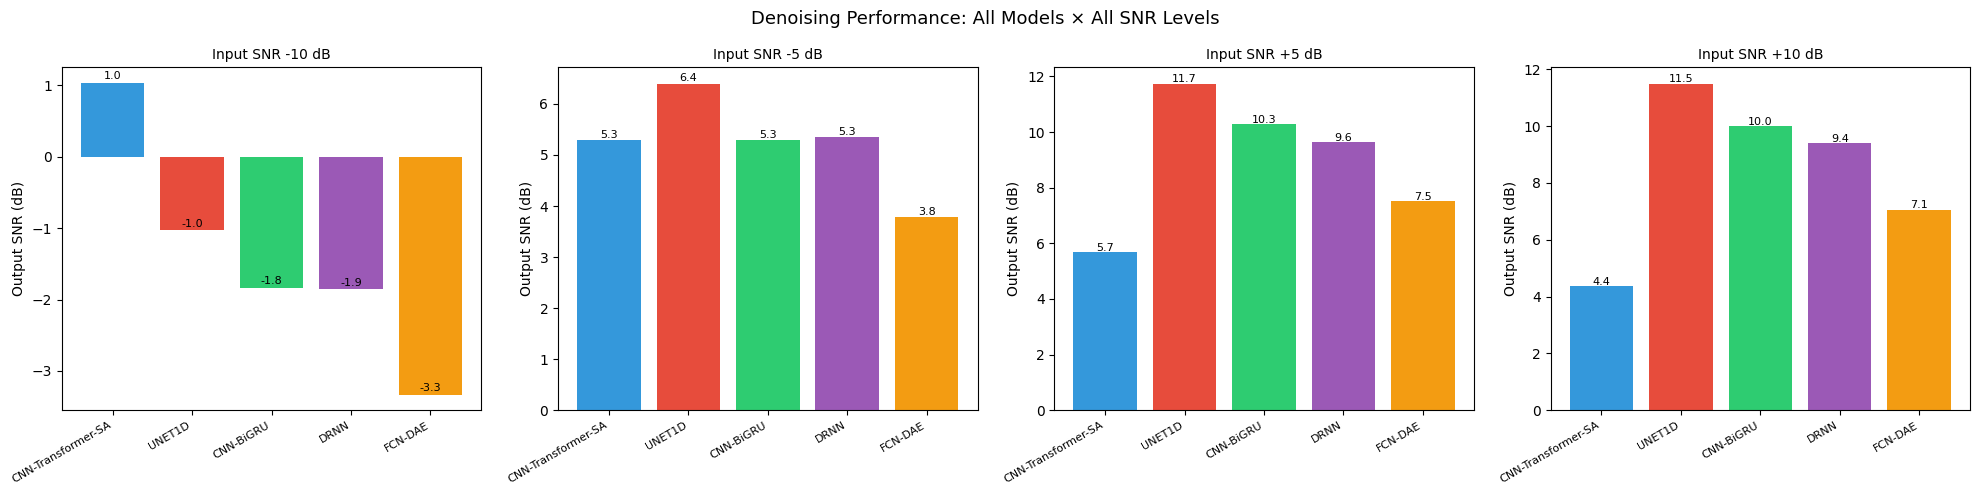

In [19]:
# ─── CELL 17 — Baseline Model Comparison ─────────────────────────────────────
print('\n=== Baseline vs Proposed Model Comparison ===')
comparison_results = {'CNN-Transformer-SA': snr_results}

for model_name, model_fn in BASELINE_CONFIGS.items():
    print(f'\nTraining {model_name}...')
    bl_model = model_fn().to(device)
    bl_ckpt  = f'{CKPT_DIR}/baseline_{model_name}.pth'

    if os.path.exists(bl_ckpt):
        bl_model.load_state_dict(torch.load(bl_ckpt, map_location=device)['model'])
        print(f'  Loaded from cache.')
    else:
        train_model(bl_model, train_loader, val_loader, criterion,
                    lr=1e-3, num_epochs=20, scheduler_type='cosine',
                    save_path=bl_ckpt, verbose=True, use_amp=True)
        bl_model.load_state_dict(torch.load(bl_ckpt, map_location=device)['model'])

    bl_model.eval()
    bl_snr = {}
    for snr_db in SNR_LEVELS:
        _, m = evaluate_denoising(bl_model, X_test_noisy_snr[snr_db], X_test_clean)
        in_snr = compute_snr(X_test_clean, X_test_noisy_snr[snr_db]).mean()
        bl_snr[snr_db] = {
            'Input SNR (dB)': float(in_snr),
            'Output SNR (dB)': m['SNR_mean'],
            'SNR Improvement (dB)': m['SNR_mean'] - float(in_snr),
            'PRD (%)': m['PRD_mean'],
            'RMSE': m['RMSE_mean'],
        }
        print(f'  {model_name} | {snr_db:+d} dB → Out SNR: {m["SNR_mean"]:+.2f} dB')
    comparison_results[model_name] = bl_snr

# Plot comparison
fig, axes = plt.subplots(1, len(SNR_LEVELS), figsize=(20, 5), sharey=False)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']
models_list = list(comparison_results.keys())
for ax, snr in zip(axes, SNR_LEVELS):
    vals = [comparison_results[m][snr]['Output SNR (dB)'] for m in models_list]
    bars = ax.bar(models_list, vals, color=colors[:len(models_list)])
    ax.set_title(f'Input SNR {snr:+d} dB', fontsize=10)
    ax.set_ylabel('Output SNR (dB)')
    ax.set_xticklabels(models_list, rotation=30, ha='right', fontsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{v:.1f}', ha='center', fontsize=8)
plt.suptitle('Denoising Performance: All Models × All SNR Levels', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison.png', dpi=150)
plt.show()


=== Ablation: Learning Rate (5 epochs each) ===
  → Best Val Loss: 0.17186
  LR=1e-04 → best val loss=0.17186
  → Best Val Loss: 0.12869
  LR=5e-04 → best val loss=0.12869
  → Best Val Loss: 0.10899
  LR=1e-03 → best val loss=0.10899
  → Best Val Loss: 0.09060
  LR=5e-03 → best val loss=0.09060


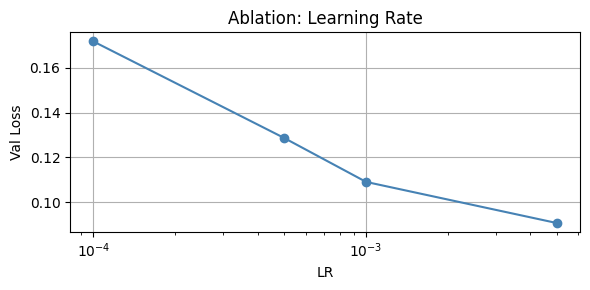

In [20]:
# ─── CELL 18 — Ablation 1: Learning Rate ─────────────────────────────────────
LR_CANDIDATES  = [1e-4, 5e-4, 1e-3, 5e-3]
lr_results     = {}

print('\n=== Ablation: Learning Rate (5 epochs each) ===')
for lr_val in LR_CANDIDATES:
    m = CNN_Transformer_SAB().to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=lr_val, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_lr_{lr_val}.pth',
                    verbose=False, use_amp=True)
    lr_results[lr_val] = min(h['val_loss'])
    print(f'  LR={lr_val:.0e} → best val loss={lr_results[lr_val]:.5f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogx(list(lr_results.keys()), list(lr_results.values()), 'o-', color='steelblue')
ax.set_title('Ablation: Learning Rate'); ax.set_xlabel('LR'); ax.set_ylabel('Val Loss')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_lr.png', dpi=150)
plt.show()



=== Ablation: Kernel Size (5 epochs each) ===
  → Best Val Loss: 0.11746
  Kernel=3 → 0.11746
  → Best Val Loss: 0.11469
  Kernel=5 → 0.11469
  → Best Val Loss: 0.11088
  Kernel=7 → 0.11088
  → Best Val Loss: 0.11074
  Kernel=9 → 0.11074
  → Best Val Loss: 0.10660
  Kernel=11 → 0.10660


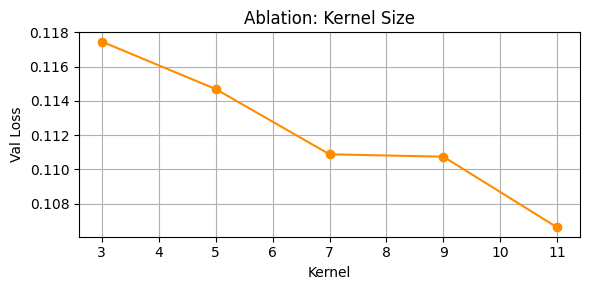

In [21]:


# ─── CELL 19 — Ablation 2: Kernel Size ───────────────────────────────────────
KERNEL_CANDIDATES = [3, 5, 7, 9, 11]
kernel_results    = {}

print('\n=== Ablation: Kernel Size (5 epochs each) ===')
for ks in KERNEL_CANDIDATES:
    m = CNN_Transformer_SAB(kernel_size=ks).to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=1e-3, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_ks_{ks}.pth',
                    verbose=False, use_amp=True)
    kernel_results[ks] = min(h['val_loss'])
    print(f'  Kernel={ks} → {kernel_results[ks]:.5f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(kernel_results.keys()), list(kernel_results.values()),
        'o-', color='darkorange')
ax.set_title('Ablation: Kernel Size'); ax.set_xlabel('Kernel'); ax.set_ylabel('Val Loss')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_kernel.png', dpi=150)
plt.show()


=== Ablation: GRU Hidden (5 epochs each) ===
  → Best Val Loss: 0.11841
  GRU hidden=16 → 0.11841
  → Best Val Loss: 0.11201
  GRU hidden=32 → 0.11201
  → Best Val Loss: 0.10113
  GRU hidden=64 → 0.10113
  → Best Val Loss: 0.09218
  GRU hidden=128 → 0.09218


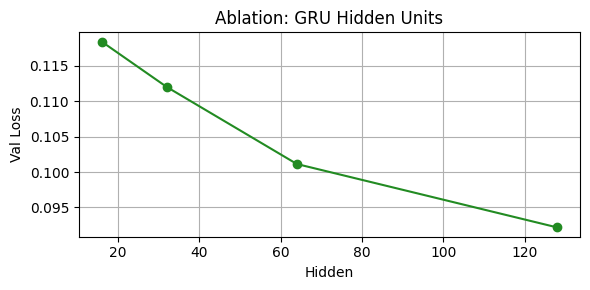

In [22]:

# ─── CELL 20 — Ablation 3: GRU Hidden Units ──────────────────────────────────
GRU_CANDIDATES = [16, 32, 64, 128]
gru_results    = {}

print('\n=== Ablation: GRU Hidden (5 epochs each) ===')
for h_dim in GRU_CANDIDATES:
    m    = CNN_Transformer_SAB(gru_hidden=h_dim).to(device)
    hist = train_model(m, train_loader, val_loader, criterion,
                       lr=1e-3, num_epochs=5, scheduler_type='cosine',
                       save_path=f'{CKPT_DIR}/abl_gru_{h_dim}.pth',
                       verbose=False, use_amp=True)
    gru_results[h_dim] = min(hist['val_loss'])
    print(f'  GRU hidden={h_dim} → {gru_results[h_dim]:.5f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(gru_results.keys()), list(gru_results.values()),
        'o-', color='forestgreen')
ax.set_title('Ablation: GRU Hidden Units'); ax.set_xlabel('Hidden'); ax.set_ylabel('Val Loss')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_gru.png', dpi=150)
plt.show()


=== Ablation: Dropout (5 epochs each) ===
  → Best Val Loss: 0.10412
  Dropout=0.0 → 0.10412
  → Best Val Loss: 0.11134
  Dropout=0.1 → 0.11134
  → Best Val Loss: 0.13434
  Dropout=0.2 → 0.13434
  → Best Val Loss: 0.15208
  Dropout=0.3 → 0.15208
  → Best Val Loss: 0.25984
  Dropout=0.5 → 0.25984


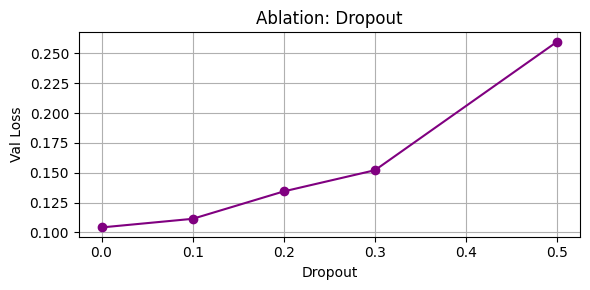

In [23]:

# ─── CELL 21 — Ablation 4: Dropout ───────────────────────────────────────────
DROPOUT_CANDIDATES = [0.0, 0.1, 0.2, 0.3, 0.5]
dropout_results    = {}

print('\n=== Ablation: Dropout (5 epochs each) ===')
for dp in DROPOUT_CANDIDATES:
    m = CNN_Transformer_SAB(dropout=dp).to(device)
    h = train_model(m, train_loader, val_loader, criterion,
                    lr=1e-3, num_epochs=5, scheduler_type='cosine',
                    save_path=f'{CKPT_DIR}/abl_dp_{dp}.pth',
                    verbose=False, use_amp=True)
    dropout_results[dp] = min(h['val_loss'])
    print(f'  Dropout={dp} → {dropout_results[dp]:.5f}')

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(dropout_results.keys()), list(dropout_results.values()),
        'o-', color='purple')
ax.set_title('Ablation: Dropout'); ax.set_xlabel('Dropout'); ax.set_ylabel('Val Loss')
ax.grid(True)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/ablation_dropout.png', dpi=150)
plt.show()

In [24]:


# ─── CELL 22 — Arrhythmia Classifier Definition ───────────────────────────────
NUM_CLASSES = len(le.classes_)

class ECGClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 32,  11, padding=5), nn.ReLU(), nn.BatchNorm1d(32),  nn.MaxPool1d(2),
            nn.Conv1d(32, 64,  7, padding=3), nn.ReLU(), nn.BatchNorm1d(64),  nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.ReLU(), nn.BatchNorm1d(128), nn.AdaptiveAvgPool1d(8),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))


class ECGClassDataset(Dataset):
    def __init__(self, signals, labels):
        self.X = torch.from_numpy(signals).unsqueeze(1)
        self.Y = torch.from_numpy(labels).long()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


def train_classifier(model, tr_ds, va_ds, num_epochs=15, lr=1e-3, tag=''):
    # FIX: num_workers=0 here too
    ld_tr = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, pin_memory=(device.type == 'cuda'))
    ld_va = DataLoader(va_ds, batch_size=BATCH_SIZE,
                       num_workers=0, pin_memory=(device.type == 'cuda'))

    opt     = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sche    = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    loss_fn = nn.CrossEntropyLoss()
    best, best_state = float('inf'), None

    for epoch in range(num_epochs):
        model.train()
        for x, y in ld_tr:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                loss = loss_fn(model(x), y)
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sche.step()

        model.eval(); v = 0.0
        with torch.no_grad():
            for x, y in ld_va:
                v += loss_fn(model(x.to(device)), y.to(device)).item()
        v /= len(ld_va)
        if v < best:
            best = v
            best_state = {k: v_.clone() for k, v_ in model.state_dict().items()}
        if (epoch + 1) % 5 == 0:
            print(f'  [{tag}] Ep {epoch+1}/{num_epochs} | Val Loss: {v:.4f}')

    model.load_state_dict(best_state)
    return model


def eval_classifier(model, signals, labels):
    ds  = ECGClassDataset(signals, labels)
    ld  = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=(device.type == 'cuda'))
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for x, y in ld:
            preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
            trues.extend(y.numpy())
    return np.array(preds), np.array(trues)


print('Classifier utilities ready.')

Classifier utilities ready.


In [25]:
# ─── CELL 23 — Train All 3 Classifiers ───────────────────────────────────────
print('Denoising train/val/test for classifier...')
X_test_denoised  = denoise_array(model, X_test_noisy,  X_test_clean)
X_train_denoised = denoise_array(model, X_train_noisy, X_train_clean)
X_val_denoised   = denoise_array(model, X_val_noisy,   X_val_clean)

print('\n=== Classifier — CLEAN ===')
clf_clean = ECGClassifier().to(device)
clf_clean = train_classifier(clf_clean,
    ECGClassDataset(X_train_clean, y_train_lbl),
    ECGClassDataset(X_val_clean,   y_val_lbl), tag='CLEAN')

print('\n=== Classifier — NOISY ===')
clf_noisy = ECGClassifier().to(device)
clf_noisy = train_classifier(clf_noisy,
    ECGClassDataset(X_train_noisy, y_train_lbl),
    ECGClassDataset(X_val_noisy,   y_val_lbl), tag='NOISY')

print('\n=== Classifier — DENOISED ===')
clf_denoised = ECGClassifier().to(device)
clf_denoised = train_classifier(clf_denoised,
    ECGClassDataset(X_train_denoised, y_train_lbl),
    ECGClassDataset(X_val_denoised,   y_val_lbl), tag='DENOISED')

Denoising train/val/test for classifier...

=== Classifier — CLEAN ===
  [CLEAN] Ep 5/15 | Val Loss: 0.0576
  [CLEAN] Ep 10/15 | Val Loss: 0.0472
  [CLEAN] Ep 15/15 | Val Loss: 0.0475

=== Classifier — NOISY ===
  [NOISY] Ep 5/15 | Val Loss: 0.1518
  [NOISY] Ep 10/15 | Val Loss: 0.1362
  [NOISY] Ep 15/15 | Val Loss: 0.1412

=== Classifier — DENOISED ===
  [DENOISED] Ep 5/15 | Val Loss: 0.1255
  [DENOISED] Ep 10/15 | Val Loss: 0.1161
  [DENOISED] Ep 15/15 | Val Loss: 0.1154



=== Classification Report Comparison ===

── CLEAN ──
              precision    recall  f1-score   support

           F     0.9000    0.6648    0.7647       176
           N     0.9910    0.9975    0.9943     42181
           Q     0.9941    0.9894    0.9917      3209
           S     0.9410    0.8074    0.8691      1028
           V     0.9701    0.9390    0.9543      2146

    accuracy                         0.9892     48740
   macro avg     0.9593    0.8796    0.9148     48740
weighted avg     0.9889    0.9892    0.9889     48740

── NOISY ──
              precision    recall  f1-score   support

           F     0.7805    0.1818    0.2949       176
           N     0.9676    0.9925    0.9799     42181
           Q     0.9683    0.9420    0.9550      3209
           S     0.8369    0.4543    0.5889      1028
           V     0.8806    0.7185    0.7914      2146

    accuracy                         0.9629     48740
   macro avg     0.8868    0.6578    0.7220     48740
weighted a

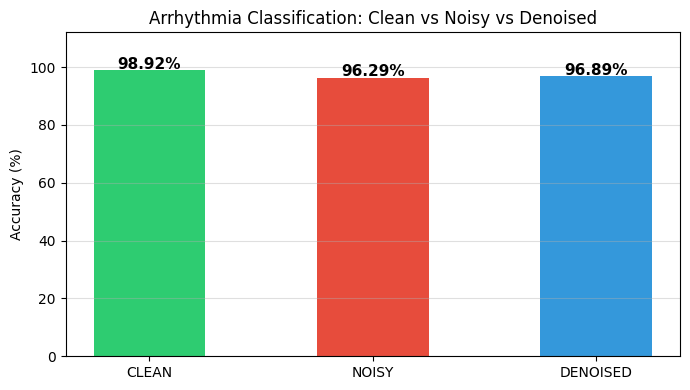

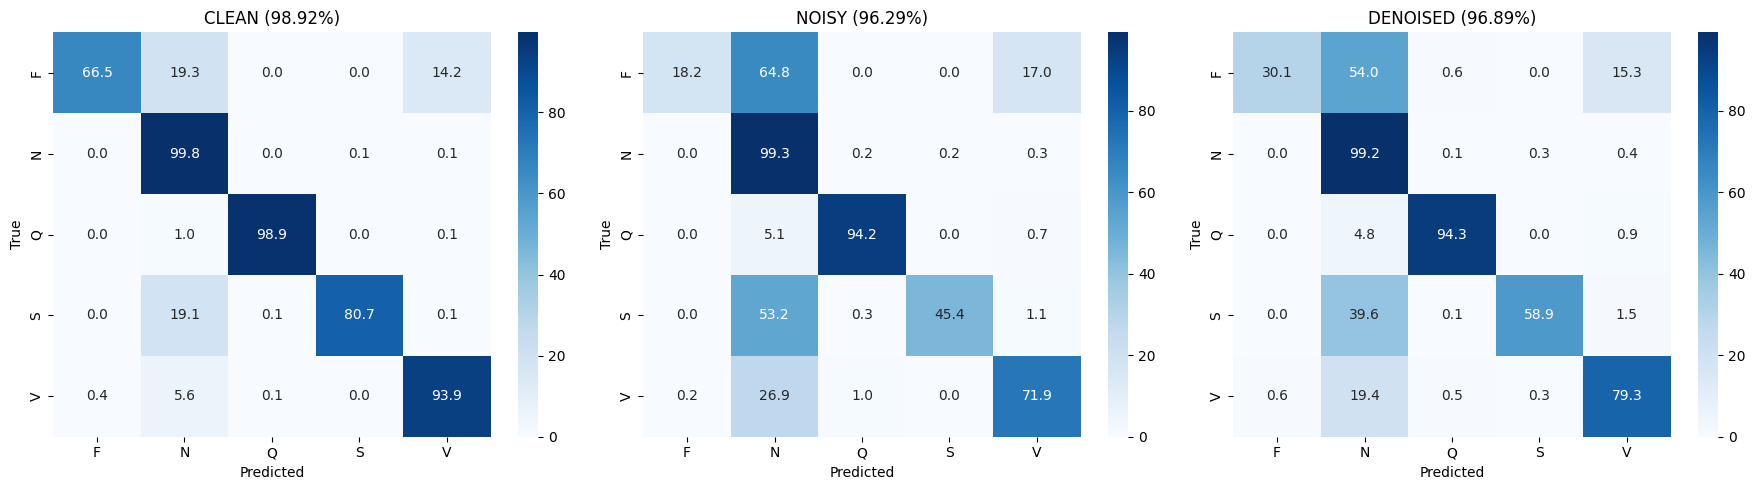

In [26]:

# ─── CELL 24 — Classification Comparison ─────────────────────────────────────
print('\n=== Classification Report Comparison ===\n')
class_names = list(le.classes_)
results_clf = {}

for tag, clf, signals in [
    ('CLEAN',    clf_clean,    X_test_clean),
    ('NOISY',    clf_noisy,    X_test_noisy),
    ('DENOISED', clf_denoised, X_test_denoised),
]:
    preds, trues = eval_classifier(clf, signals, y_test_lbl)
    acc = (preds == trues).mean() * 100
    results_clf[tag] = {'accuracy': acc, 'preds': preds, 'trues': trues}
    print(f'── {tag} ──')
    print(classification_report(trues, preds, target_names=class_names, digits=4))

# Accuracy bar chart
fig, ax = plt.subplots(figsize=(7, 4))
tags  = list(results_clf.keys())
accs  = [results_clf[t]['accuracy'] for t in tags]
bars  = ax.bar(tags, accs, color=['#2ecc71', '#e74c3c', '#3498db'], width=0.5)
ax.set_ylim(0, 112); ax.set_ylabel('Accuracy (%)')
ax.set_title('Arrhythmia Classification: Clean vs Noisy vs Denoised')
ax.grid(axis='y', alpha=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/classification_comparison.png', dpi=150)
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (tag, res) in zip(axes, results_clf.items()):
    cm = confusion_matrix(res['trues'], res['preds'])
    sns.heatmap(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100,
                annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{tag} ({res["accuracy"]:.2f}%)')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=150)
plt.show()


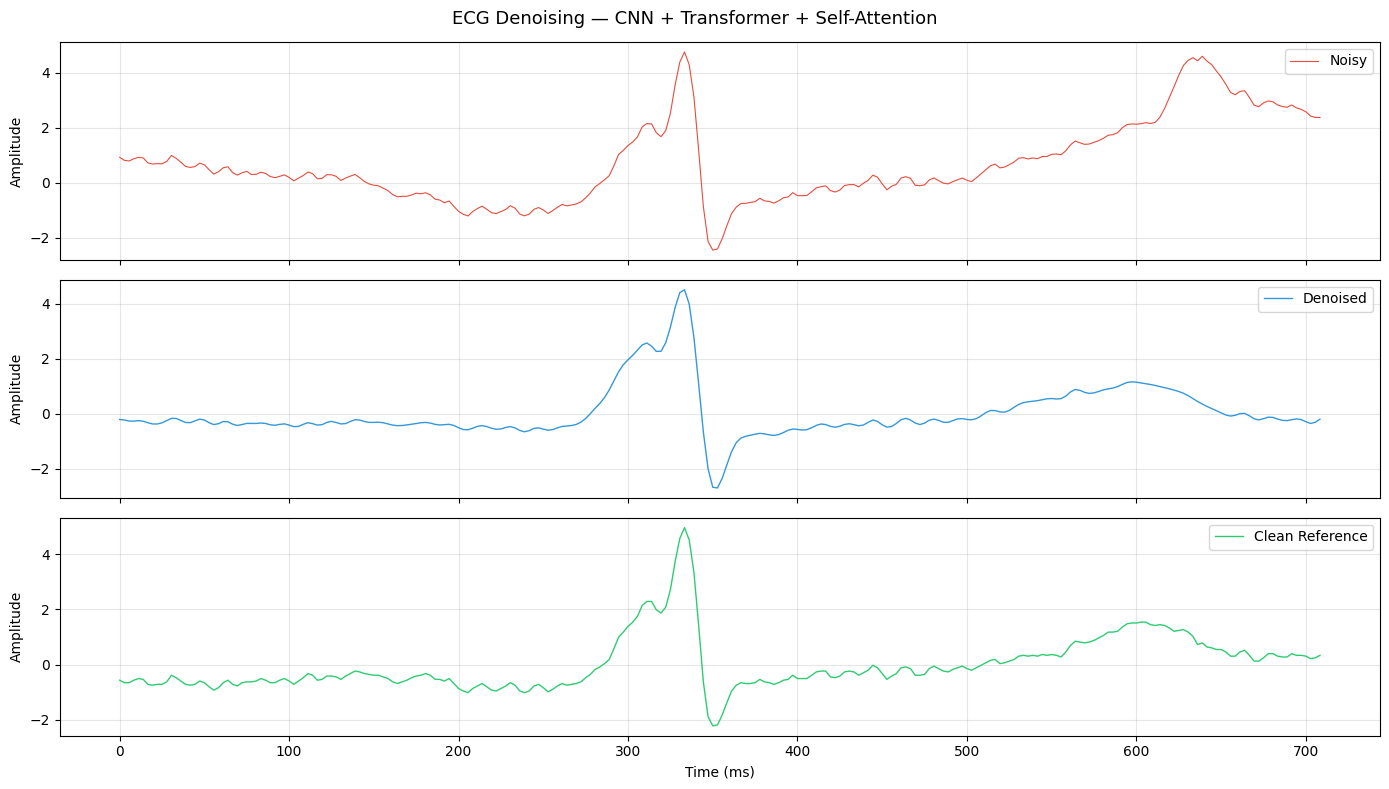

In [27]:

# ─── CELL 25 — Waveform Visualization ────────────────────────────────────────
IDX = 0
t   = np.arange(WINDOW_LEN) / FS * 1000

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)
axes[0].plot(t, X_test_noisy[IDX],    color='#e74c3c', lw=0.8, label='Noisy')
axes[1].plot(t, X_test_denoised[IDX], color='#3498db', lw=1.0, label='Denoised')
axes[2].plot(t, X_test_clean[IDX],    color='#2ecc71', lw=1.0, label='Clean Reference')
for ax in axes:
    ax.legend(loc='upper right'); ax.set_ylabel('Amplitude'); ax.grid(alpha=0.3)
axes[2].set_xlabel('Time (ms)')
plt.suptitle('ECG Denoising — CNN + Transformer + Self-Attention', fontsize=13)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/waveform_comparison.png', dpi=150)
plt.show()

In [28]:
# ─── CELL 26 — Final Summary & CSV Export ────────────────────────────────────
preds_final, _ = evaluate_denoising(model, X_test_noisy, X_test_clean)
snr_out  = compute_snr(X_test_clean,  preds_final)
snr_in   = compute_snr(X_test_clean,  X_test_noisy)
prd_out  = compute_prd(X_test_clean,  preds_final)
rmse_out = compute_rmse(X_test_clean, preds_final)

pd.DataFrame({
    'index':           np.arange(len(preds_final)),
    'label':           le.inverse_transform(y_test_lbl),
    'SNR_input_dB':    snr_in,
    'SNR_output_dB':   snr_out,
    'SNR_improvement': snr_out - snr_in,
    'PRD':             prd_out,
    'RMSE':            rmse_out,
}).to_csv(f'{RESULTS_DIR}/final_test_metrics.csv', index=False)

print('\n' + '='*60)
print('FINAL RESULTS SUMMARY')
print('='*60)
print(f'  Input  SNR : {snr_in.mean():.3f} dB')
print(f'  Output SNR : {snr_out.mean():.3f} dB')
print(f'  SNR Δ      : {(snr_out - snr_in).mean():.3f} dB')
print(f'  PRD        : {prd_out.mean():.4f} %')
print(f'  RMSE       : {rmse_out.mean():.6f}')
print('\nArrhythmia Classification Accuracy:')
for tag, res in results_clf.items():
    print(f'  {tag:>9s}: {res["accuracy"]:.2f}%')
print('\nBest Hyperparameters from Ablation:')
print(f'  LR          : {min(lr_results, key=lr_results.get):.0e}')
print(f'  Kernel size : {min(kernel_results, key=kernel_results.get)}')
print(f'  GRU hidden  : {min(gru_results, key=gru_results.get)}')
print(f'  Dropout     : {min(dropout_results, key=dropout_results.get)}')
print(f'\n✅  All results saved to {RESULTS_DIR}')


FINAL RESULTS SUMMARY
  Input  SNR : -1.366 dB
  Output SNR : 12.814 dB
  SNR Δ      : 14.180 dB
  PRD        : 25.3604 %
  RMSE       : 0.253604

Arrhythmia Classification Accuracy:
      CLEAN: 98.92%
      NOISY: 96.29%
   DENOISED: 96.89%

Best Hyperparameters from Ablation:
  LR          : 5e-03
  Kernel size : 11
  GRU hidden  : 128
  Dropout     : 0.0

✅  All results saved to /content/drive/MyDrive/ecg_denoising_v3/results
